In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from scipy.sparse import csr_matrix, hstack
import matplotlib.pyplot as plt


In [2]:
# =========================================================
# 1. LOAD DATA
# =========================================================
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

possible_labels = [
    "asih",
    "nyakitang",
    "kaadilan",
    "kacurangan",
    "setya",
    "ngianat",
    "wewenang",
    "ngalawan tatanan",
    "kasucian",
    "kakotoran",
    "kabebasan",
    "panindasan"
]

# pastikan semua label ada di dataframe
for lab in possible_labels:
    if lab not in train_df.columns:
        raise ValueError(f"Label '{lab}' tidak ditemukan di train_df")
    if lab not in test_df.columns:
        raise ValueError(f"Label '{lab}' tidak ditemukan di test_df")

# teks
X_train_text = train_df["sentence"].astype(str)
X_test_text = test_df["sentence"].astype(str)

In [3]:

# =========================================================
# 1B. KEYWORD FEATURES
# =========================================================
moral_keyword_dict = {
    "asih": ["pitresnan", "tulus", "ampura", "matimpal", "ngubadin", "bagia", "kasih", "sayang", "menolong", "peduli"],
    "nyakitang": ["nyakitang", "pedih", "tampaha", "tuna", "ngutah", "ngentak", "melukai", "menyakiti", "kekerasan", "mati"],
    "kaadilan": ["kaadilan", "adil", "upah", "upahina", "karma", "gelahang", "setara", "hak", "jujur", "fair"],
    "kacurangan": ["kacurangan", "curang", "ngekadaya", "nyaru", "mamaling", "bohong", "menipu", "licik", "tipu", "daya"],
    "setya": ["setya", "setia", "mabakti", "ngiring", "amanah", "loyal", "taat", "patuh", "janji", "bakti"],
    "ngianat": ["ngianat", "khianat", "berkhianat", "mengingkari", "membelot", "uluk", "kerkuak", "melog"],
    "wewenang": ["wewenang", "otoritas", "kuasa", "parama", "aturanga", "ingetang", "ngandikain", "pemimpin", "perintah", "aturan"],
    "ngalawan tatanan": ["ngalawan", "tatanan", "aduanga", "tajene", "matajen", "iri", "ngrengkeng", "melawan", "memberontak", "melanggar"],
    "kasucian": ["kasucian", "suci", "hyang", "widhi", "betara", "bhatara", "rsi", "yadnya", "mantra", "nugraha"],
    "kakotoran": ["kakotoran", "kotor", "najis", "caru", "ngisep", "cetik", "kanikayang", "ngengkebang", "cemar", "jijik"],
    "kabebasan": ["kabebasan", "bebas", "merdeka", "lega", "liang", "atine", "pilihan", "mandiri", "otonomi"],
    "panindasan": ["panindasan", "menindas", "penindasan", "matianga", "nyagrep", "tampaha", "tendasne", "memaksa", "menekan", "mengekang"]
}

def simple_tokenize(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()


def build_keyword_matrix(text_series, keyword_dict, labels_order):
    rows = []
    for text in text_series.astype(str):
        tokens = simple_tokenize(text)
        token_counts = {}
        for tok in tokens:
            token_counts[tok] = token_counts.get(tok, 0) + 1

        row = []
        for label in labels_order:
            lexicon = keyword_dict[label]
            score = 0.0
            for token in lexicon:
                score += token_counts.get(token, 0)
            row.append(np.log1p(score))
        rows.append(row)

    return csr_matrix(np.array(rows, dtype=np.float32))

X_train_keyword = build_keyword_matrix(X_train_text, moral_keyword_dict, possible_labels)
X_test_keyword = build_keyword_matrix(X_test_text, moral_keyword_dict, possible_labels)

print("Shape X_train_keyword:", X_train_keyword.shape)
print("Shape X_test_keyword :", X_test_keyword.shape)


Shape X_train_keyword: (5214, 12)
Shape X_test_keyword : (1304, 12)


In [4]:

# =========================================================
# 2. TF-IDF VECTORIZATION + KEYWORD FEATURES
# =========================================================
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

# Gabungkan TF-IDF dengan fitur keyword
X_train = hstack([X_train_tfidf, X_train_keyword], format="csr")
X_test = hstack([X_test_tfidf, X_test_keyword], format="csr")

print("Shape X_train_tfidf   :", X_train_tfidf.shape)
print("Shape X_test_tfidf    :", X_test_tfidf.shape)
print("Shape X_train_keyword :", X_train_keyword.shape)
print("Shape X_test_keyword  :", X_test_keyword.shape)
print("Shape X_train_final   :", X_train.shape)
print("Shape X_test_final    :", X_test.shape)


Shape X_train_tfidf   : (5214, 10000)
Shape X_test_tfidf    : (1304, 10000)
Shape X_train_keyword : (5214, 12)
Shape X_test_keyword  : (1304, 12)
Shape X_train_final   : (5214, 10012)
Shape X_test_final    : (1304, 10012)


In [7]:
# =========================================================
# 3. SIAPKAN FOLDER SIMPAN
# =========================================================
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/ML_MoralClassifier/LR_keyword"
os.makedirs(BASE_DIR, exist_ok=True)

print("Folder penyimpanan:", BASE_DIR)

# simpan vectorizer sekali saja
joblib.dump(vectorizer, os.path.join(BASE_DIR, "tfidf_vectorizer.pkl"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan: /content/drive/MyDrive/ML_MoralClassifier/LR_keyword


['/content/drive/MyDrive/ML_MoralClassifier/LR_keyword/tfidf_vectorizer.pkl']


Processing label: asih


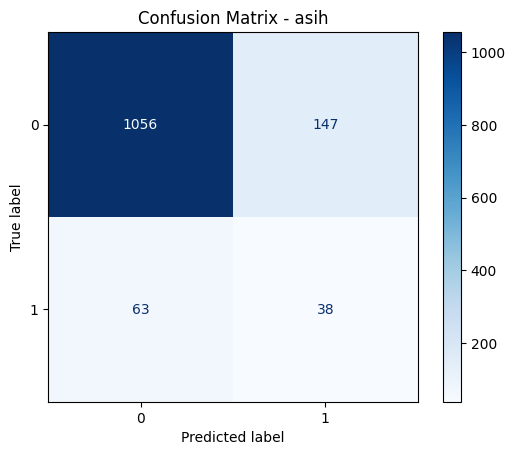

Best threshold : 0.45
F1 Score       : 0.2657
Precision      : 0.2054
Recall         : 0.3762
Accuracy       : 0.8390

Confusion Matrix:
[[1056  147]
 [  63   38]]

TN = 1056
FP = 147
FN = 63
TP = 38

Confusion Matrix Table:
          Pred 0  Pred 1
Actual 0    1056     147
Actual 1      63      38

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.88      0.91      1203
           1       0.21      0.38      0.27       101

    accuracy                           0.84      1304
   macro avg       0.57      0.63      0.59      1304
weighted avg       0.89      0.84      0.86      1304


Processing label: nyakitang


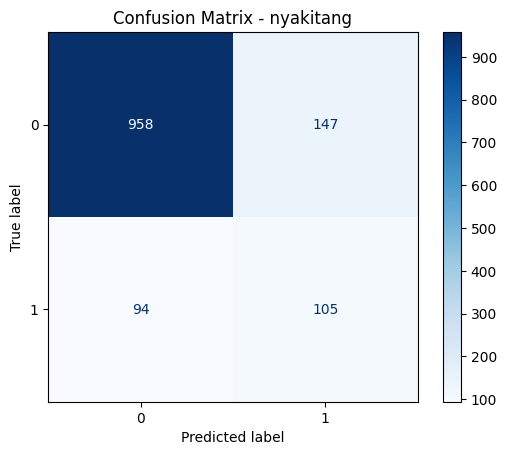

Best threshold : 0.50
F1 Score       : 0.4656
Precision      : 0.4167
Recall         : 0.5276
Accuracy       : 0.8152

Confusion Matrix:
[[958 147]
 [ 94 105]]

TN = 958
FP = 147
FN = 94
TP = 105

Confusion Matrix Table:
          Pred 0  Pred 1
Actual 0     958     147
Actual 1      94     105

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1105
           1       0.42      0.53      0.47       199

    accuracy                           0.82      1304
   macro avg       0.66      0.70      0.68      1304
weighted avg       0.84      0.82      0.82      1304


Processing label: kaadilan


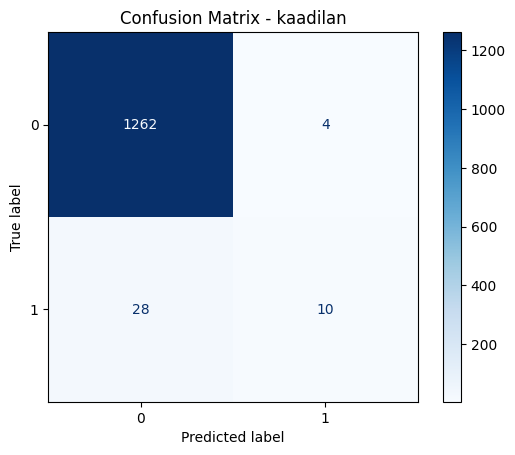

Best threshold : 0.70
F1 Score       : 0.3846
Precision      : 0.7143
Recall         : 0.2632
Accuracy       : 0.9755

Confusion Matrix:
[[1262    4]
 [  28   10]]

TN = 1262
FP = 4
FN = 28
TP = 10

Confusion Matrix Table:
          Pred 0  Pred 1
Actual 0    1262       4
Actual 1      28      10

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1266
           1       0.71      0.26      0.38        38

    accuracy                           0.98      1304
   macro avg       0.85      0.63      0.69      1304
weighted avg       0.97      0.98      0.97      1304


Processing label: kacurangan


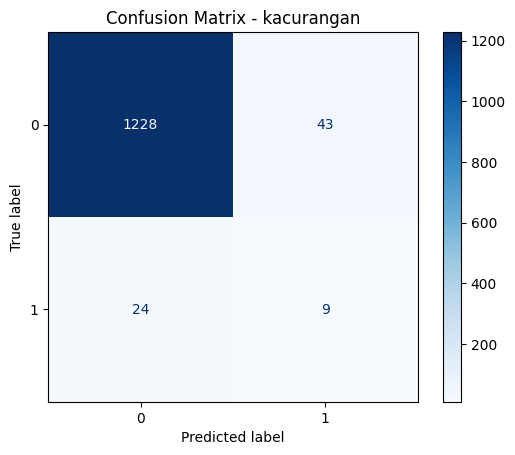

Best threshold : 0.45
F1 Score       : 0.2118
Precision      : 0.1731
Recall         : 0.2727
Accuracy       : 0.9486

Confusion Matrix:
[[1228   43]
 [  24    9]]

TN = 1228
FP = 43
FN = 24
TP = 9

Confusion Matrix Table:
          Pred 0  Pred 1
Actual 0    1228      43
Actual 1      24       9

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1271
           1       0.17      0.27      0.21        33

    accuracy                           0.95      1304
   macro avg       0.58      0.62      0.59      1304
weighted avg       0.96      0.95      0.95      1304


Processing label: setya


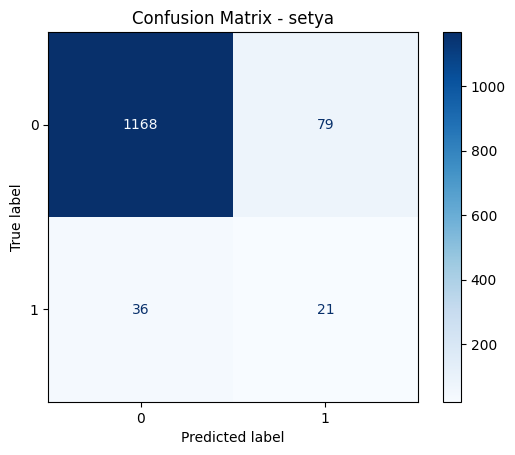

Best threshold : 0.45
F1 Score       : 0.2675
Precision      : 0.2100
Recall         : 0.3684
Accuracy       : 0.9118

Confusion Matrix:
[[1168   79]
 [  36   21]]

TN = 1168
FP = 79
FN = 36
TP = 21

Confusion Matrix Table:
          Pred 0  Pred 1
Actual 0    1168      79
Actual 1      36      21

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.95      1247
           1       0.21      0.37      0.27        57

    accuracy                           0.91      1304
   macro avg       0.59      0.65      0.61      1304
weighted avg       0.94      0.91      0.92      1304


Processing label: ngianat


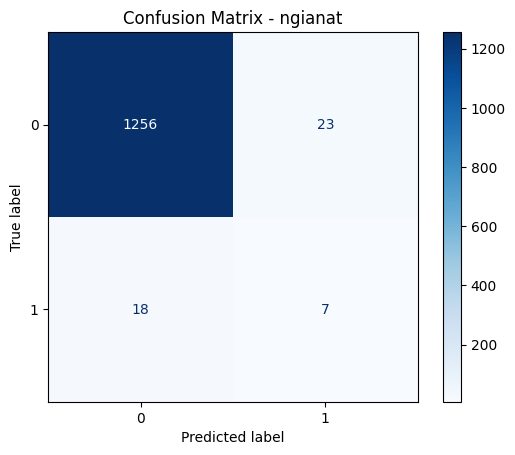

Best threshold : 0.50
F1 Score       : 0.2545
Precision      : 0.2333
Recall         : 0.2800
Accuracy       : 0.9686

Confusion Matrix:
[[1256   23]
 [  18    7]]

TN = 1256
FP = 23
FN = 18
TP = 7

Confusion Matrix Table:
          Pred 0  Pred 1
Actual 0    1256      23
Actual 1      18       7

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1279
           1       0.23      0.28      0.25        25

    accuracy                           0.97      1304
   macro avg       0.61      0.63      0.62      1304
weighted avg       0.97      0.97      0.97      1304


Processing label: wewenang


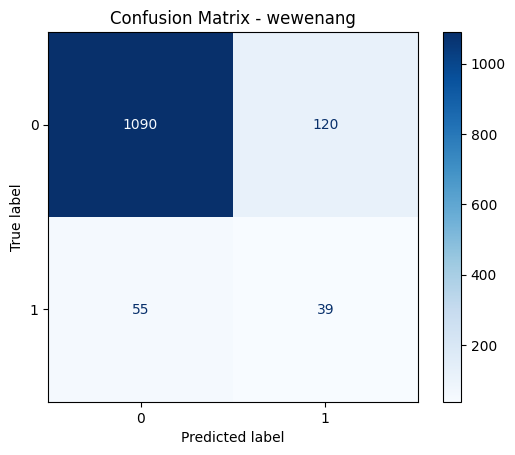

Best threshold : 0.50
F1 Score       : 0.3083
Precision      : 0.2453
Recall         : 0.4149
Accuracy       : 0.8658

Confusion Matrix:
[[1090  120]
 [  55   39]]

TN = 1090
FP = 120
FN = 55
TP = 39

Confusion Matrix Table:
          Pred 0  Pred 1
Actual 0    1090     120
Actual 1      55      39

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.90      0.93      1210
           1       0.25      0.41      0.31        94

    accuracy                           0.87      1304
   macro avg       0.60      0.66      0.62      1304
weighted avg       0.90      0.87      0.88      1304


Processing label: ngalawan tatanan


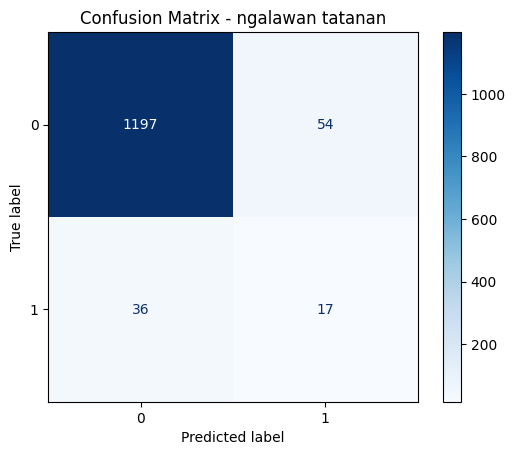

Best threshold : 0.50
F1 Score       : 0.2742
Precision      : 0.2394
Recall         : 0.3208
Accuracy       : 0.9310

Confusion Matrix:
[[1197   54]
 [  36   17]]

TN = 1197
FP = 54
FN = 36
TP = 17

Confusion Matrix Table:
          Pred 0  Pred 1
Actual 0    1197      54
Actual 1      36      17

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      1251
           1       0.24      0.32      0.27        53

    accuracy                           0.93      1304
   macro avg       0.61      0.64      0.62      1304
weighted avg       0.94      0.93      0.94      1304


Processing label: kasucian


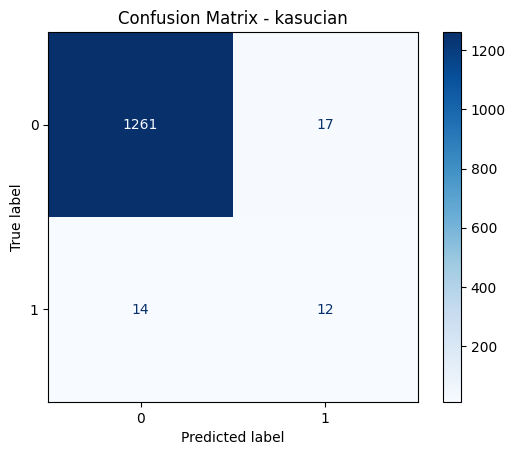

Best threshold : 0.65
F1 Score       : 0.4364
Precision      : 0.4138
Recall         : 0.4615
Accuracy       : 0.9762

Confusion Matrix:
[[1261   17]
 [  14   12]]

TN = 1261
FP = 17
FN = 14
TP = 12

Confusion Matrix Table:
          Pred 0  Pred 1
Actual 0    1261      17
Actual 1      14      12

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1278
           1       0.41      0.46      0.44        26

    accuracy                           0.98      1304
   macro avg       0.70      0.72      0.71      1304
weighted avg       0.98      0.98      0.98      1304


Processing label: kakotoran


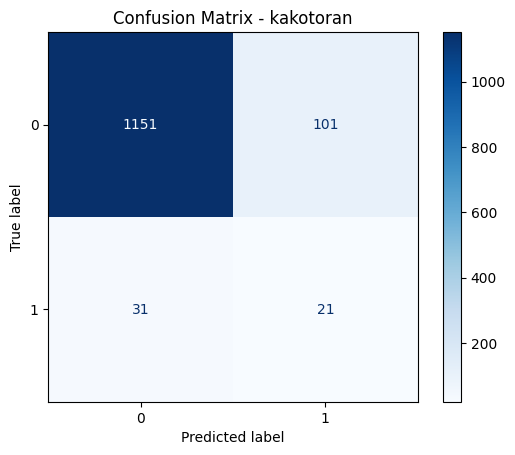

Best threshold : 0.40
F1 Score       : 0.2414
Precision      : 0.1721
Recall         : 0.4038
Accuracy       : 0.8988

Confusion Matrix:
[[1151  101]
 [  31   21]]

TN = 1151
FP = 101
FN = 31
TP = 21

Confusion Matrix Table:
          Pred 0  Pred 1
Actual 0    1151     101
Actual 1      31      21

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.95      1252
           1       0.17      0.40      0.24        52

    accuracy                           0.90      1304
   macro avg       0.57      0.66      0.59      1304
weighted avg       0.94      0.90      0.92      1304


Processing label: kabebasan


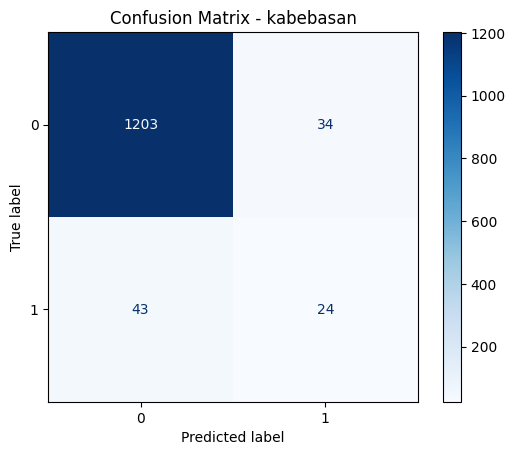

Best threshold : 0.60
F1 Score       : 0.3840
Precision      : 0.4138
Recall         : 0.3582
Accuracy       : 0.9410

Confusion Matrix:
[[1203   34]
 [  43   24]]

TN = 1203
FP = 34
FN = 43
TP = 24

Confusion Matrix Table:
          Pred 0  Pred 1
Actual 0    1203      34
Actual 1      43      24

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1237
           1       0.41      0.36      0.38        67

    accuracy                           0.94      1304
   macro avg       0.69      0.67      0.68      1304
weighted avg       0.94      0.94      0.94      1304


Processing label: panindasan


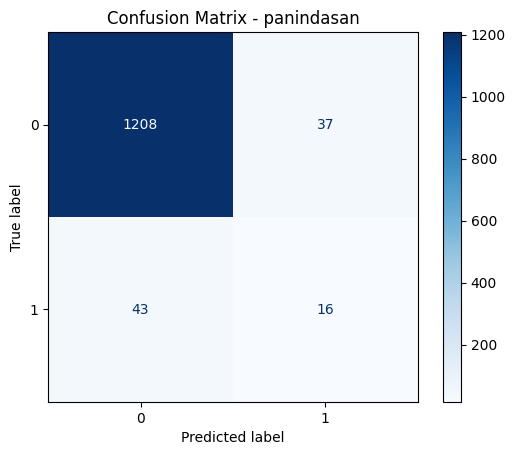

Best threshold : 0.60
F1 Score       : 0.2857
Precision      : 0.3019
Recall         : 0.2712
Accuracy       : 0.9387

Confusion Matrix:
[[1208   37]
 [  43   16]]

TN = 1208
FP = 37
FN = 43
TP = 16

Confusion Matrix Table:
          Pred 0  Pred 1
Actual 0    1208      37
Actual 1      43      16

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1245
           1       0.30      0.27      0.29        59

    accuracy                           0.94      1304
   macro avg       0.63      0.62      0.63      1304
weighted avg       0.94      0.94      0.94      1304



In [8]:
# =========================================================
# 4. TRAINING PER LABEL
# =========================================================
summary_rows = []
threshold_dict = {}
predictions = []

# inisialisasi dataframe prediksi
for i in range(len(test_df)):
    predictions.append({
        "sentence": test_df.iloc[i]["sentence"]
    })

for lab in possible_labels:
    print(f"\n{'='*60}")
    print(f"Processing label: {lab}")

    y_train = train_df[lab].astype(int).values
    y_test = test_df[lab].astype(int).values

    # model LR
    model = LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    )

    # training
    model.fit(X_train, y_train)

    # probabilitas kelas positif
    y_prob = model.predict_proba(X_test)[:, 1]

    # threshold tuning
    best_f1 = -1
    best_th = 0.5
    best_pred = None

    for th in np.arange(0.05, 1.00, 0.05):
        temp_pred = (y_prob >= th).astype(int)
        temp_f1 = f1_score(y_test, temp_pred, average="binary", zero_division=0)

        if temp_f1 > best_f1:
            best_f1 = temp_f1
            best_th = float(th)
            best_pred = temp_pred.copy()

    # metrik final pakai best threshold
    precision = precision_score(y_test, best_pred, average="binary", zero_division=0)
    recall = recall_score(y_test, best_pred, average="binary", zero_division=0)
    acc = accuracy_score(y_test, best_pred)

    # confusion matrix
    cm = confusion_matrix(y_test, best_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {lab}")
    plt.show()

    print(f"Best threshold : {best_th:.2f}")
    print(f"F1 Score       : {best_f1:.4f}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"Accuracy       : {acc:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    print("\nTN =", tn)
    print("FP =", fp)
    print("FN =", fn)
    print("TP =", tp)

    cm_df = pd.DataFrame(
        cm,
        index=["Actual 0", "Actual 1"],
        columns=["Pred 0", "Pred 1"]
    )
    print("\nConfusion Matrix Table:")
    print(cm_df)

    print("\nClassification Report:")
    print(classification_report(y_test, best_pred, zero_division=0))

    # simpan model per label
    safe_lab = lab.replace(" ", "_")
    joblib.dump(model, os.path.join(BASE_DIR, f"lr_{safe_lab}.pkl"))

    # simpan threshold
    threshold_dict[lab] = best_th

    # simpan ringkasan
    summary_rows.append({
        "label": lab,
        "best_threshold": best_th,
        "f1_binary": best_f1,
        "precision_binary": precision,
        "recall_binary": recall,
        "accuracy": acc,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "positive_train_count": int(y_train.sum()),
        "positive_test_count": int(y_test.sum())
    })

    # simpan prediksi per sampel
    for i in range(len(test_df)):
        predictions[i][f"true_{lab}"] = int(y_test[i])
        predictions[i][f"prob_{lab}"] = float(y_prob[i])
        predictions[i][f"pred_{lab}"] = int(best_pred[i])

In [ ]:

# =========================================================
# 5. SIMPAN HASIL
# =========================================================
summary_df = pd.DataFrame(summary_rows)
predictions_df = pd.DataFrame(predictions)

summary_df.to_csv(os.path.join(BASE_DIR, "lr_augmented_keyword_summary_per_label.csv"), index=False)
predictions_df.to_csv(os.path.join(BASE_DIR, "lr_augmented_keyword_predictions_12labels.csv"), index=False)
joblib.dump(vectorizer, os.path.join(BASE_DIR, "tfidf_vectorizer_keyword.pkl"))
joblib.dump(moral_keyword_dict, os.path.join(BASE_DIR, "keyword_lexicon.pkl"))

with open(os.path.join(BASE_DIR, "best_thresholds_keyword.json"), "w", encoding="utf-8") as f:
    json.dump(threshold_dict, f, ensure_ascii=False, indent=2)

print(f"Semua model dan hasil tersimpan di folder: {BASE_DIR}")
print("Summary:")
print(summary_df)
